# Trabalho de DL - Gerador de Digitos Fake (GAN) - G13

(usando PyTorch)


### 1. Importando bibliotecas

In [1]:
# ==========================================
# Bibliotecas padrão
# ==========================================
import os
import time
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

# ==========================================
# PyTorch
# ==========================================
import torch
import torch.nn as nn
import torch.optim as optim

from torch.utils.data import DataLoader
from torchvision import datasets
from torchvision import transforms
from torchvision.utils import make_grid

# ==========================================
# Utilidades
# ==========================================
from IPython.display import Image, display, clear_output



### 2. Garantindo a reprodutibilidade

In [2]:
# Semente para reprodutibilidade
SEED = 13 # Em homenagem ao Grupo!

torch.manual_seed(SEED)
np.random.seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

### 3. Detecção de Recurso GPU

In [3]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print(f"Dispositivo: {device}")

if device.type == "cuda":
    print(torch.cuda.get_device_name(0))

Dispositivo: cuda
Tesla T4


### 4. Hiperparâmetros e Dataloader

In [4]:
# ==========================================
# Hiperparâmetros
# ==========================================

BATCH_SIZE = 256
IMAGE_SIZE = 28

# ==========================================
# Transformações
# ==========================================

transform = transforms.Compose([
    transforms.ToTensor(),                 # [0,255] -> [0,1]
    transforms.Normalize((0.5,), (0.5,))   # [0,1] -> [-1,1]
])

# ==========================================
# Dataset MNIST
# ==========================================

train_dataset = datasets.MNIST(
    root="./data",
    train=True,
    download=True,
    transform=transform
)

# ==========================================
# DataLoader
# ==========================================

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    drop_last=True,
    num_workers=2,
    pin_memory=torch.cuda.is_available()
)

print(f"Número de imagens : {len(train_dataset):,}")
print(f"Número de batches : {len(train_loader)}")

Número de imagens : 60,000
Número de batches : 234


In [5]:
images, labels = next(iter(train_loader))

print(images.shape)
print(labels.shape)

torch.Size([256, 1, 28, 28])
torch.Size([256])


### 5. Testar Imagens

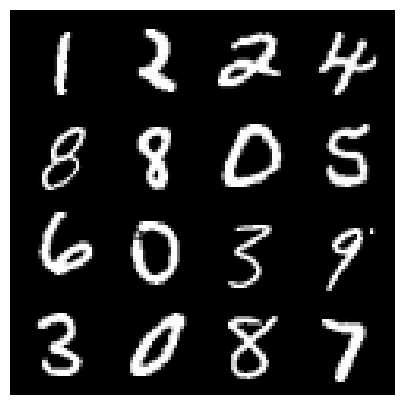

In [6]:
images, _ = next(iter(train_loader))

grid = make_grid(
    images[:16],
    nrow=4,
    normalize=True
)

plt.figure(figsize=(5, 5))
plt.imshow(grid.permute(1, 2, 0).cpu())
plt.axis("off")
plt.show()

### 6. Generator

In [7]:
# ==========================================
# Gerador (Generator)
# ==========================================

class Generator(nn.Module):

    def __init__(self, latent_dim=100):
        super().__init__()

        self.model = nn.Sequential(

            # (batch, 100)
            nn.Linear(latent_dim, 7 * 7 * 256, bias=False),

            nn.BatchNorm1d(7 * 7 * 256),
            nn.LeakyReLU(0.2, inplace=True),

            # (batch,12544) -> (batch,256,7,7)
            nn.Unflatten(1, (256, 7, 7)),

            # 7x7 -> 7x7
            nn.ConvTranspose2d(
                256,
                128,
                kernel_size=5,
                stride=1,
                padding=2,
                bias=False
            ),

            nn.BatchNorm2d(128),
            nn.LeakyReLU(0.2, inplace=True),

            # 7x7 -> 14x14
            nn.ConvTranspose2d(
                128,
                64,
                kernel_size=5,
                stride=2,
                padding=2,
                output_padding=1,
                bias=False
            ),

            nn.BatchNorm2d(64),
            nn.LeakyReLU(0.2, inplace=True),

            # 14x14 -> 28x28
            nn.ConvTranspose2d(
                64,
                1,
                kernel_size=5,
                stride=2,
                padding=2,
                output_padding=1,
                bias=False
            ),

            nn.Tanh()
        )

    def forward(self, x):
        return self.model(x)

In [8]:
LATENT_DIM = 100

generator = Generator(LATENT_DIM).to(device)

print(generator)

Generator(
  (model): Sequential(
    (0): Linear(in_features=100, out_features=12544, bias=False)
    (1): BatchNorm1d(12544, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): LeakyReLU(negative_slope=0.2, inplace=True)
    (3): Unflatten(dim=1, unflattened_size=(256, 7, 7))
    (4): ConvTranspose2d(256, 128, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2), bias=False)
    (5): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): LeakyReLU(negative_slope=0.2, inplace=True)
    (7): ConvTranspose2d(128, 64, kernel_size=(5, 5), stride=(2, 2), padding=(2, 2), output_padding=(1, 1), bias=False)
    (8): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (9): LeakyReLU(negative_slope=0.2, inplace=True)
    (10): ConvTranspose2d(64, 1, kernel_size=(5, 5), stride=(2, 2), padding=(2, 2), output_padding=(1, 1), bias=False)
    (11): Tanh()
  )
)


In [9]:
noise = torch.randn(16, LATENT_DIM, device=device)

fake_images = generator(noise)

print(fake_images.shape)

torch.Size([16, 1, 28, 28])


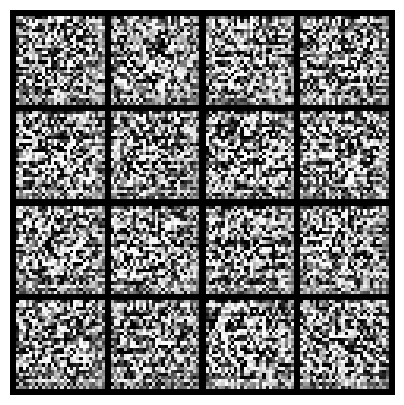

In [10]:
with torch.no_grad():

    fake_images = generator(torch.randn(16, LATENT_DIM, device=device)).cpu()

grid = make_grid(
    fake_images,
    nrow=4,
    normalize=True
)

plt.figure(figsize=(5,5))
plt.imshow(grid.permute(1,2,0))
plt.axis("off")
plt.show()

### 7. Discriminator

In [11]:
# ==========================================
# Discriminador (Discriminator)
# ==========================================

class Discriminator(nn.Module):

    def __init__(self):
        super().__init__()

        self.model = nn.Sequential(

            # Entrada: (batch, 1, 28, 28)

            # 28x28 -> 14x14
            nn.Conv2d(
                in_channels=1,
                out_channels=64,
                kernel_size=5,
                stride=2,
                padding=2
            ),

            nn.LeakyReLU(0.2, inplace=True),
            nn.Dropout(0.3),

            # 14x14 -> 7x7
            nn.Conv2d(
                in_channels=64,
                out_channels=128,
                kernel_size=5,
                stride=2,
                padding=2
            ),

            nn.LeakyReLU(0.2, inplace=True),
            nn.Dropout(0.3),

            nn.Flatten(),

            nn.Linear(7 * 7 * 128, 1)
        )

    def forward(self, x):
        return self.model(x)

In [12]:
discriminator = Discriminator().to(device)

print(discriminator)

Discriminator(
  (model): Sequential(
    (0): Conv2d(1, 64, kernel_size=(5, 5), stride=(2, 2), padding=(2, 2))
    (1): LeakyReLU(negative_slope=0.2, inplace=True)
    (2): Dropout(p=0.3, inplace=False)
    (3): Conv2d(64, 128, kernel_size=(5, 5), stride=(2, 2), padding=(2, 2))
    (4): LeakyReLU(negative_slope=0.2, inplace=True)
    (5): Dropout(p=0.3, inplace=False)
    (6): Flatten(start_dim=1, end_dim=-1)
    (7): Linear(in_features=6272, out_features=1, bias=True)
  )
)


### 8. Testar o discriminador

In [13]:
images, _ = next(iter(train_loader))

images = images.to(device)

output = discriminator(images)

print(output.shape)

torch.Size([256, 1])


In [14]:
noise = torch.randn(BATCH_SIZE, LATENT_DIM, device=device)

with torch.no_grad():
    fake_images = generator(noise)

output = discriminator(fake_images)

print(output.shape)

torch.Size([256, 1])


### 9. Função de perda

In [15]:
# Função de perda
criterion = nn.BCEWithLogitsLoss()

In [16]:
def generator_loss(fake_output):

    target = torch.ones_like(fake_output)

    return criterion(fake_output, target)


def discriminator_loss(real_output, fake_output):

    real_target = torch.ones_like(real_output)
    fake_target = torch.zeros_like(fake_output)

    real_loss = criterion(real_output, real_target)
    fake_loss = criterion(fake_output, fake_target)

    return real_loss + fake_loss

### 10. Otimizador

In [17]:
# Otimizador
generator_optimizer = optim.Adam(
    generator.parameters(),
    lr=1e-4
)

discriminator_optimizer = optim.Adam(
    discriminator.parameters(),
    lr=1e-4
)

### 11. Função que treina o gerador e discriminador

In [18]:
LATENT_DIM = 100

def train_step(real_images):

    batch_size = real_images.size(0)

    real_images = real_images.to(device)

    noise = torch.randn(
        batch_size,
        LATENT_DIM,
        device=device
    )

    # =====================================================
    # Treinamento do Discriminador
    # =====================================================

    discriminator_optimizer.zero_grad()

    fake_images = generator(noise)

    real_output = discriminator(real_images)
    fake_output = discriminator(fake_images.detach())

    disc_loss = discriminator_loss(
        real_output,
        fake_output
    )

    disc_loss.backward()

    discriminator_optimizer.step()

    # =====================================================
    # Treinamento do Gerador
    # =====================================================

    generator_optimizer.zero_grad()

    fake_images = generator(noise)

    fake_output = discriminator(fake_images)

    gen_loss = generator_loss(fake_output)

    gen_loss.backward()

    generator_optimizer.step()

    return gen_loss.item(), disc_loss.item()

### 12. Checkpoints

In [19]:
CHECKPOINT_DIR = Path("training_checkpoints")
CHECKPOINT_DIR.mkdir(exist_ok=True)

In [20]:
# Salva

def save_checkpoint(epoch):

    checkpoint = {

        "epoch": epoch,

        "generator_state_dict":
            generator.state_dict(),

        "discriminator_state_dict":
            discriminator.state_dict(),

        "generator_optimizer_state_dict":
            generator_optimizer.state_dict(),

        "discriminator_optimizer_state_dict":
            discriminator_optimizer.state_dict()

    }

    filename = CHECKPOINT_DIR / f"gan_epoch_{epoch:04d}.pth"

    torch.save(checkpoint, filename)

    print(f"Checkpoint salvo em: {filename}")

In [21]:
# checkpoint = {
#     "epoch": epoch,
#     "generator_loss": gen_loss,
#     "discriminator_loss": disc_loss,
#     "generator_state_dict": generator.state_dict(),
#     "discriminator_state_dict": discriminator.state_dict(),
#     "generator_optimizer_state_dict": generator_optimizer.state_dict(),
#     "discriminator_optimizer_state_dict": discriminator_optimizer.state_dict()
# }

In [22]:
# Carrega

def load_checkpoint(filename):

    checkpoint = torch.load(
        filename,
        map_location=device
    )

    generator.load_state_dict(
        checkpoint["generator_state_dict"]
    )

    discriminator.load_state_dict(
        checkpoint["discriminator_state_dict"]
    )

    generator_optimizer.load_state_dict(
        checkpoint["generator_optimizer_state_dict"]
    )

    discriminator_optimizer.load_state_dict(
        checkpoint["discriminator_optimizer_state_dict"]
    )

    epoch = checkpoint["epoch"]

    print(f"Checkpoint carregado: época {epoch}")

    return epoch

In [23]:
SAVE_EVERY = 15

# for epoch in range(NUM_EPOCHS):

#     ...

#     if (epoch + 1) % SAVE_EVERY == 0:
#         save_checkpoint(epoch + 1)

In [24]:
# last_epoch = load_checkpoint(
#     "training_checkpoints/gan_epoch_0015.pth"
# )

In [25]:
# start_epoch = load_checkpoint(
#     "training_checkpoints/gan_epoch_0015.pth"
# )

# for epoch in range(start_epoch, NUM_EPOCHS):

#     ...

### 13. Geração de imagem durante o treinamento

In [26]:
NUM_EXAMPLES = 16
LATENT_DIM = 100

fixed_noise = torch.randn(
    NUM_EXAMPLES,
    LATENT_DIM,
    device=device
)

In [27]:
OUTPUT_DIR = Path("images")
OUTPUT_DIR.mkdir(exist_ok=True)

def generate_and_save_images(model, epoch, noise):
    model.eval()

    with torch.no_grad():
        predictions = model(noise).cpu()

    # [-1,1] -> [0,1]
    predictions = (predictions + 1) / 2

    fig = plt.figure(figsize=(4, 4))

    for i in range(predictions.size(0)):

        plt.subplot(4, 4, i + 1)

        plt.imshow(
            predictions[i, 0],
            cmap="gray",
            vmin=0,
            vmax=1
        )

        plt.axis("off")

    filename = OUTPUT_DIR / f"image_at_epoch_{epoch:04d}.png"

    plt.tight_layout()
    plt.savefig(filename)
    plt.close(fig)
    
    clear_output(wait=True)
    display(Image(filename))

    model.train()

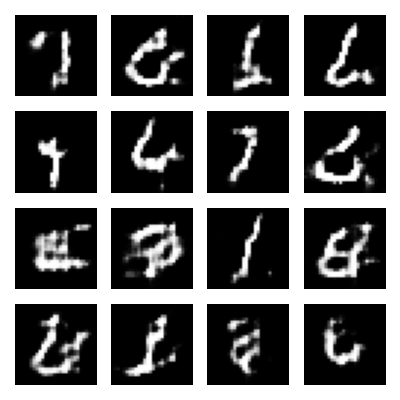

Época  20 | G: 1.3347 | D: 0.9420
Time for epoch 20 is 17.82 sec


In [ ]:
NUM_EPOCHS = 20

for epoch in range(NUM_EPOCHS):
    #TODO: Deletar checkpoints antigos
    start = time.time()
    
    for real_images, _ in train_loader:

        gen_loss, disc_loss = train_step(real_images)

    generate_and_save_images(
        generator,
        epoch + 1,
        fixed_noise
    )

    print(
        f"Época {epoch+1:3d} | "
        f"G: {gen_loss:.4f} | "
        f"D: {disc_loss:.4f}"
    )
    print (f'Time for epoch {epoch + 1} is {(time.time()-start):.2f} sec')
    
    if (epoch + 1) % SAVE_EVERY == 0:
        save_checkpoint(epoch + 1)


In [29]:
import imageio.v2 as imageio

IMAGE_DIR = Path("images")
GIF_NAME = "dcgan.gif"

image_files = sorted(IMAGE_DIR.glob("image_at_epoch_*.png"))

with imageio.get_writer(
    GIF_NAME,
    mode="I",
    duration=0.3,
    loop=0
) as writer:

    # Adiciona todas as épocas
    for image_file in image_files:
        writer.append_data(imageio.imread(image_file))

    # Mantém a última imagem por mais tempo
    last_image = imageio.imread(image_files[-1])

    for _ in range(10):
        writer.append_data(last_image)

print(f"GIF salvo em: {GIF_NAME}")

GIF salvo em: dcgan.gif


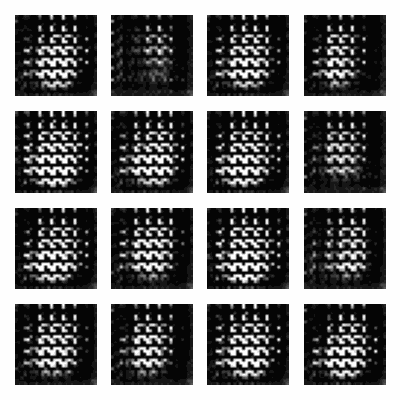

In [30]:
display(Image(filename=GIF_NAME))